# Just a quick notebook to visualize and understand what are the outputs of the SuPreM algorithm performed on the TotalSegmentator dataset

In [1]:
import nibabel as nib
import numpy as np

Let's visualize the results of the first image.

In [2]:
index_image = 100 # with tree digits
path_folder_result_0 = f"/cis/home/ezribi1/my_documents/fair_segmentation/results/s0{str(index_image)}"
path_folder_segmentation_0 = f"/cis/home/ezribi1/my_documents/fair_segmentation/results/s0{str(index_image)}/segmentations"
path_stomach_file_0 = f"{path_folder_segmentation_0}/stomach.nii.gz"

Read combined_labels file.

In [3]:
def basic_info_on_nifti_image(path ):
    # Load the NIfTI image
    img = nib.load(path)

    # Get the data array as a NumPy array
    data = img.get_fdata()        # shape: (X, Y, Z) or (X, Y, Z, T)

    print("Image shape:", data.shape)
    print("Data type:", data.dtype)
    print("Unique labels:", np.unique(data))

Ok so we see that the combined_labels output the result of image segmentation for all the different organs.

Let's open the first file of the segmentation folder.

In [4]:
# basic_info_on_nifti_image(f"/cis/home/ezribi1/my_documents/fair_segmentation/results/s0001/segmentations/stomach.nii.gz")

In [5]:
basic_info_on_nifti_image(path_stomach_file_0)

Image shape: (91, 91, 121)
Data type: float64
Unique labels: [0.00000000e+00 2.95077723e-39 3.04444563e-39 ... 9.91638958e-01
 9.93065059e-01 9.93368924e-01]


We see that in the results of the stomatch file, there is only the results of the binary image segmentation for the stomach.

### Load the file and inspect

👉 What to look for:

If values are exactly 0 and 1 → it's likely a binary mask

If values ∈ [0,1] and vary smoothly → probably a probability map h_i(x)

If values like 0.45 or 0.6 everywhere → maybe threshold map λ(x)

If shape is (X,Y,Z,2) → likely [ground truth, prediction]

In [6]:
import nibabel as nib
import numpy as np

path = path_stomach_file_0
img = nib.load(path)
data = img.get_fdata()  # shape: (X, Y, Z) or maybe (X, Y, Z, C)

print("Prediction:")
print("Shape:", data.shape)
print("Min/Max:", np.min(data), np.max(data))
print("Unique values:", np.unique(data))
print("Number of unique values:", len(np.unique(data)))


Prediction:
Shape: (91, 91, 121)
Min/Max: 0.0 0.993368923664093
Unique values: [0.00000000e+00 2.95077723e-39 3.04444563e-39 ... 9.91638958e-01
 9.93065059e-01 9.93368924e-01]
Number of unique values: 365839


### Check if you have access to the original image and ground truth mask
If stomach.nii.gz only contains the predicted probabilities, then you’ll likely need to also load:

- The original CT image (e.g. ct.nii.gz)

- The ground truth mask (e.g. labels.nii.gz or stomach_gt.nii.gz)

You can try exploring the folder:

In [7]:
path_gt_stomach = f"/export/gaon1/data/jteneggi/TotalSegmentator/s0{str(index_image)}/segmentations/stomach.nii.gz"
path_ct_image = f"/export/gaon1/data/jteneggi/TotalSegmentator/s0{str(index_image)}/ct.nii.gz"

In [8]:
img = nib.load(path_gt_stomach)
data = img.get_fdata()  # shape: (X, Y, Z) or maybe (X, Y, Z, C)

print("Ground Truth Stomach:")
print("Shape:", data.shape)
print("Min/Max:", np.min(data), np.max(data))
print("Unique values:", np.unique(data))
print("Number of unique values:", len(np.unique(data)))

Ground Truth Stomach:
Shape: (91, 91, 121)
Min/Max: 0.0 0.0
Unique values: [0.]
Number of unique values: 1


In [9]:
img = nib.load(path_ct_image)
data = img.get_fdata()  # shape: (X, Y, Z) or maybe (X, Y, Z, C)

print("Original CT image:")
print("Shape:", data.shape)
print("Min/Max:", np.min(data), np.max(data))
print("Unique values:", np.unique(data))
print("Number of unique values:", len(np.unique(data)))

Original CT image:
Shape: (91, 91, 121)
Min/Max: -1029.0 2190.0
Unique values: [-1029. -1028. -1027. ...  2116.  2165.  2190.]
Number of unique values: 3009


### Acess to demographic groups in meta.csv

In [10]:
path_meta = f"/export/gaon1/data/jteneggi/TotalSegmentator/meta.csv"

import pandas as pd
meta_df = pd.read_csv(path_meta, sep=";")
print("Meta Data:")
meta_df

Meta Data:


,image_id,age,gender,institute,study_type,split,manufacturer,scanner_model,kvp,pathology,pathology_location
0,s1366,50.0,NaN,I,ct polytrauma,train,siemens,sensation 64,120.0,unclear,unclear
1,s0245,77.0,m,I,ct abdomen-pelvis,train,siemens,somatom definition flash,100.0,no_pathology,no_location
2,s0325,65.0,f,I,ct abdomen-pelvis,train,siemens,sensation 64,120.0,other,abdomen
3,s0320,80.0,m,I,ct angiography abdomen-pelvis-leg,train,siemens,sensation 64,120.0,vascular,abdomen
4,s0193,63.0,m,C,ct abdomen-pelvis,train,siemens,emotion 16,130.0,no_pathology,no_location
...,...,...,...,...,...,...,...,...,...,...,...
1223,s1425,NaN,NaN,NaN,NaN,test,NaN,NaN,NaN,NaN,NaN
1224,s1426,68.0,m,NaN,NaN,test,ge,lightspeed pro 16,120.0,NaN,NaN
1225,s1427,23.0,m,NaN,NaN,test,ge,lightspeed16,120.0,NaN,NaN
1226,s1428,66.0,m,NaN,NaN,test,ge,discovery mi,120.0,NaN,NaN


Age


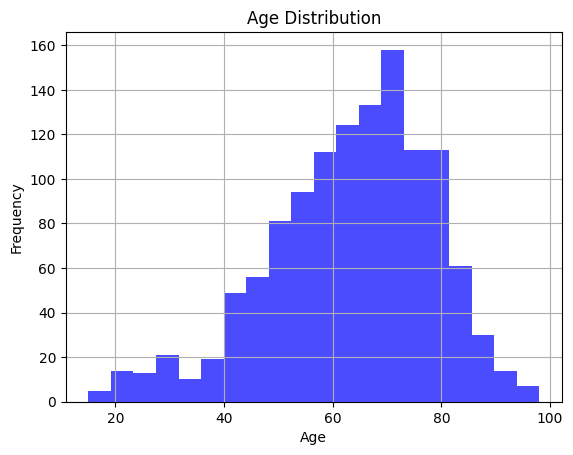

In [11]:
print("Age")
import matplotlib.pyplot as plt
plt.hist(meta_df['age'], bins=20, color='blue', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.grid()
plt.show()

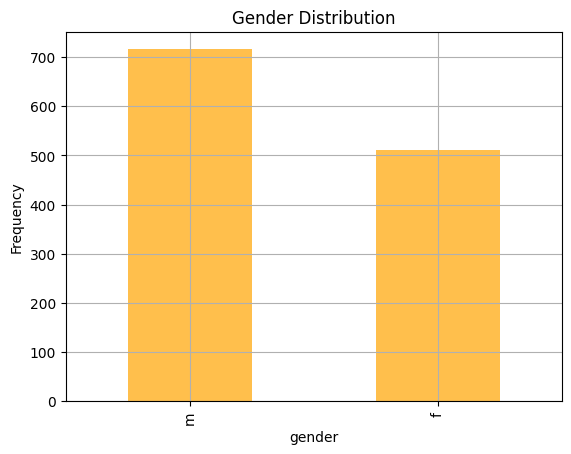

In [12]:
meta_df['gender'].value_counts().plot(kind='bar', color='orange', alpha=0.7)
plt.ylabel('Frequency')
plt.title("Gender Distribution")
plt.grid()
plt.show()

In [13]:
unique_genders, gender_counts = np.unique(meta_df['gender'].astype(str), return_counts=True)
list(zip(unique_genders, gender_counts))

[('f', 510), ('m', 716), ('nan', 2)]

### Visualize original vs. predicted vs. ground truth


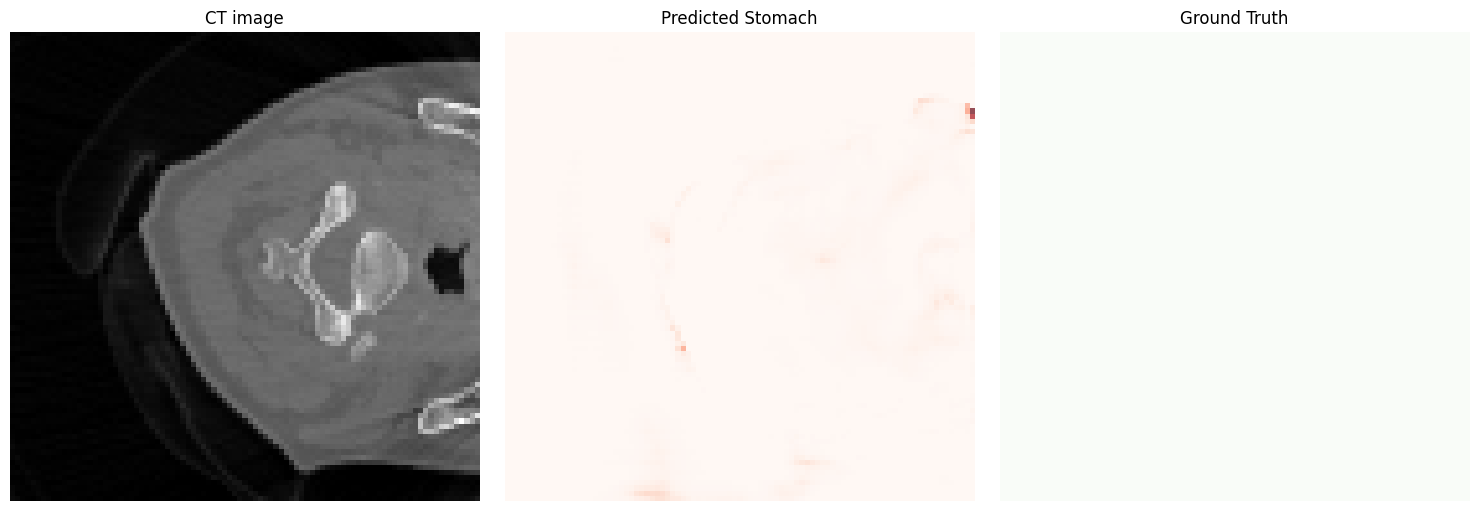

In [14]:
import matplotlib.pyplot as plt

def show_stomach_slices(ct_path, pred_path, gt_path=None, slice_idx=None):
    ct = nib.load(ct_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()
    if gt_path:
        gt = nib.load(gt_path).get_fdata()
    else:
        gt = None

    if slice_idx is None:
        slice_idx = ct.shape[2] // 2  # central axial slice

    fig, axs = plt.subplots(1, 3 if gt is not None else 2, figsize=(15, 5))
    axs[0].imshow(ct[:, :, slice_idx], cmap="gray")
    axs[0].set_title("CT image")

    axs[1].imshow(pred[:, :, slice_idx], cmap="Reds", alpha=0.7)
    axs[1].set_title("Predicted Stomach")

    if gt is not None:
        axs[2].imshow(gt[:, :, slice_idx], cmap="Greens", alpha=0.7)
        axs[2].set_title("Ground Truth")

    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example usage
show_stomach_slices(path_ct_image, path_stomach_file_0, path_gt_stomach)


### Verify that all images have the same format

In [27]:
import os
import nibabel as nib

totalsegmentator_path = "/export/gaon1/data/jteneggi/TotalSegmentator"
shapes = set()
list_shapes=[]
number_of_pixels=[]

for folder in os.listdir(totalsegmentator_path):
    if folder.startswith("s"):
        ct_path = os.path.join(totalsegmentator_path, folder, "ct.nii.gz")
        if os.path.exists(ct_path):
            shape = nib.load(ct_path).shape
            shapes.add(shape)
            list_shapes.append(shape)
            number_of_pixels.append(np.prod(shape))

print(shapes)

{(165, 113, 165), (202, 202, 252), (310, 310, 247), (240, 240, 281), (221, 221, 217), (333, 333, 38), (129, 129, 62), (232, 232, 96), (274, 274, 320), (253, 253, 181), (223, 223, 80), (246, 209, 200), (74, 122, 366), (247, 247, 299), (108, 108, 127), (147, 147, 107), (194, 193, 336), (305, 305, 461), (238, 158, 421), (233, 233, 294), (201, 201, 261), (304, 304, 239), (254, 254, 397), (309, 309, 209), (250, 250, 169), (236, 236, 421), (268, 268, 311), (261, 261, 459), (220, 196, 196), (118, 118, 269), (288, 288, 293), (251, 251, 191), (51, 74, 154), (109, 92, 111), (142, 184, 247), (281, 281, 220), (333, 333, 415), (311, 311, 90), (277, 218, 277), (253, 143, 170), (260, 260, 144), (290, 245, 199), (279, 178, 481), (206, 160, 137), (432, 193, 349), (272, 272, 303), (258, 258, 317), (225, 225, 267), (241, 241, 265), (265, 265, 388), (299, 190, 483), (212, 212, 205), (178, 168, 168), (249, 249, 130), (242, 242, 40), (127, 127, 168), (95, 94, 105), (321, 321, 402), (247, 247, 47), (239, 239

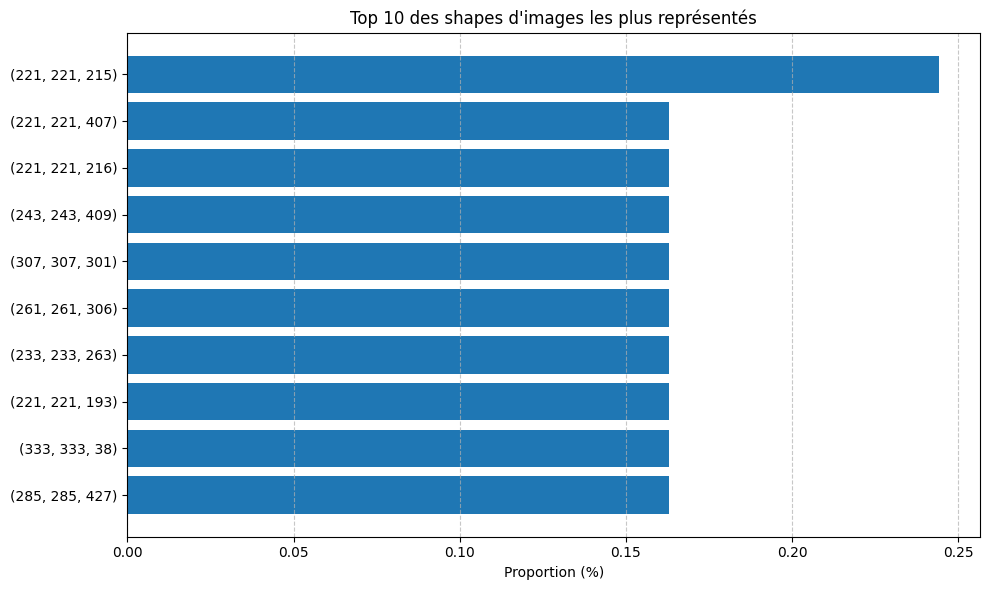

In [23]:
from collections import Counter
# Compter les occurrences de chaque shape
shape_counts = Counter(list_shapes)
total = sum(shape_counts.values())

# Garder les 10 shapes les plus fréquents
top_10 = shape_counts.most_common(10)
shapes_labels = [str(shape) for shape, _ in top_10]
proportions = [count / total * 100 for _, count in top_10]

# Tracer
plt.figure(figsize=(10, 6))
plt.barh(shapes_labels[::-1], proportions[::-1])  # inverser pour que le plus grand soit en haut
plt.xlabel("Proportion (%)")
plt.title("Top 10 des shapes d'images les plus représentés")
plt.tight_layout()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()